<a href="https://colab.research.google.com/github/sahdahx/PDS/blob/main/PDS_T10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas 10: Hypothesis Testing in Practice - Pengantar Data Sains**
> Nama: Sahda Huwaidah Estiningtyas

> NIM: 24/545080/PA/23156

> email: sahdahuwaidahestiningtyas@mail.ugm.ac.id

# **Assignment - Week 10**

Gunakan **1 dataset publik** atau dataset sintetis yang Anda rancang sendiri, lalu lakukan analisis uji hipotesis dengan tahapan berikut.

## Soal

### 1. Jelaskan dataset yang digunakan
Jelaskan:

- nama dataset,
- sumber dataset atau alasan pembuatan dataset sintetis,
- unit analisis,
- variabel utama,
- jenis variabel: numerik atau kategorik.

### 2. Muat dataset ke Python menggunakan `pandas`
Tampilkan:

- `shape`,
- `head()`,
- `info()`,
- ringkasan variabel utama.

### 3. Lakukan eksplorasi awal
Tampilkan minimal:

- statistik deskriptif,
- histogram untuk variabel numerik,
- boxplot untuk membandingkan kelompok,
- tabel frekuensi untuk variabel kategorik.

### 4. Rumuskan minimal 3 uji hipotesis
Minimal mencakup:

1. satu uji untuk rata-rata atau proporsi satu sampel,
2. satu uji untuk membandingkan dua kelompok,
3. satu uji untuk variabel kategorik atau lebih dari dua kelompok.

Untuk setiap uji, tuliskan:

- parameter yang diuji,
- $H_0$,
- $H_A$,
- tingkat signifikansi $\alpha$,
- alasan memilih uji tersebut.

### 5. Jalankan uji menggunakan Python
Untuk setiap uji, tampilkan:

- statistik uji,
- p-value,
- keputusan uji,
- interpretasi dalam konteks data.

### 6. Bahas makna praktis
Jelaskan apakah hasil yang signifikan secara statistik juga penting secara praktis. Jika memungkinkan, laporkan effect size.

### 7. Kesimpulan akhir
Buat kesimpulan 1–2 paragraf yang menjawab pertanyaan penelitian berdasarkan hasil uji.

## 1) Deskripsi Dataset

Dataset yang digunakan adalah **[Global Stock Market Trading Value](https://www.kaggle.com/datasets/omarshahrukh/stocks-traded-total-value-current-us)** yang bersumber dari World Bank (World Development Indicators).

Dataset ini mencakup periode waktu yang panjang, yaitu dari tahun 1975 hingga 2024 sehingga dapat dikategorikan sebagai data time series (deret waktu) dengan dimensi lintas negara.

Unit analisis pada dataset ini adalah **country-year**, di mana setiap baris merepresentasikan satu negara pada satu tahun tertentu dengan nilai aktivitas pasar saham yang tercatat.
Dataset ini menggambarkan total nilai transaksi pasar saham sebagai indikator aktivitas dan likuiditas pasar keuangan global.

Variabel utama dalam dataset meliputi:

* `country`: nama negara atau wilayah
* `year`: tahun observasi (1975–2024)
* `stock_trading_value`: total nilai transaksi pasar saham dalam USD

## 2) Memuat Dataset

Pada tahap awal, dataset dimuat ke Python agar dapat dianalisis lebih lanjut. Pemeriksaan awal seperti ukuran data, tipe variabel, dan beberapa baris pertama penting dilakukan untuk memahami struktur dataset sebelum melakukan analisis statistik.

In [ ]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

# Membaca data
df = pd.read_csv("stocks_traded_total_value.csv")

# Menampilkan ukuran dataset
print("Shape dataset:")
print(df.shape)

# Menampilkan 5 data pertama
print("\nHead dataset:")
display(df.head())

# Informasi dataset
print("\nInfo dataset:")
df.info()

# Mengecek missing value
print("\nMissing values:")
print(df.isnull().sum())

Shape dataset:
(4080, 4)

Head dataset:


,Country Name,Year,Value (USD),Status
0,Arab World,2006,1.585737e+12,Normal value
1,Arab World,2010,3.069249e+11,Normal value
2,Arab World,2011,3.792060e+11,Normal value
3,Arab World,2012,5.984638e+11,Normal value
4,Arab World,2014,8.071476e+11,Normal value



Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4080 entries, 0 to 4079
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  4080 non-null   object 
 1   Year          4080 non-null   int64  
 2   Value (USD)   4080 non-null   float64
 3   Status        4080 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 127.6+ KB

Missing values:
Country Name    0
Year            0
Value (USD)     0
Status          0
dtype: int64


**Interpretasi:**

### a) Shape dataset

Dataset memiliki ukuran **(4080, 4)** yang berarti terdapat 4080 observasi (baris data) dan 4 variabel (kolom).

### b) Head dataset

Lima baris pertama menunjukkan bahwa dataset berisi informasi mengenai:

* nama negara atau wilayah,
* tahun observasi,
* total nilai transaksi pasar saham dalam USD,
* status data.

Nilai `Value (USD)` memiliki skala yang sangat besar (mencapai triliunan USD) sehingga dapat diasumsikan bahwa distribusi data kemungkinan tidak simetris dan berpotensi memiliki skewness tinggi.

### c) Info dataset

Berdasarkan hasil `info()`, dataset memiliki:

* Dua variabel numerik, yaitu `Year` bertipe `int64` dan `Value (USD)` bertipe `float64`

* Dua variabel kategorik, yaitu `Country Name` dan `Status`.

Seluruh variabel memiliki **4080 non-null values** sehingga dataset tidak memiliki missing values dan dapat langsung digunakan untuk analisis statistik tanpa proses imputasi data.

### d) Missing values

Hasil pemeriksaan missing values menunjukkan seluruh variabel memiliki nilai **0 missing values**. Hal ini berarti dataset lengkap dan tidak memerlukan proses penanganan data hilang (*missing value handling*) sebelum dilakukan eksplorasi data maupun uji hipotesis.

## 3) Eksplorasi Data

Eksplorasi awal dilakukan untuk memahami distribusi data, mendeteksi outlier, dan melihat pola antar kelompok. Visualisasi seperti histogram dan boxplot membantu interpretasi data sebelum melakukan uji hipotesis.

Statistik deskriptif Value (USD):


,Value (USD)
count,4.080000e+03
mean,3.391412e+12
std,1.142855e+13
min,0.000000e+00
25%,1.242955e+09
50%,3.583474e+10
75%,6.890408e+11
max,1.206482e+14


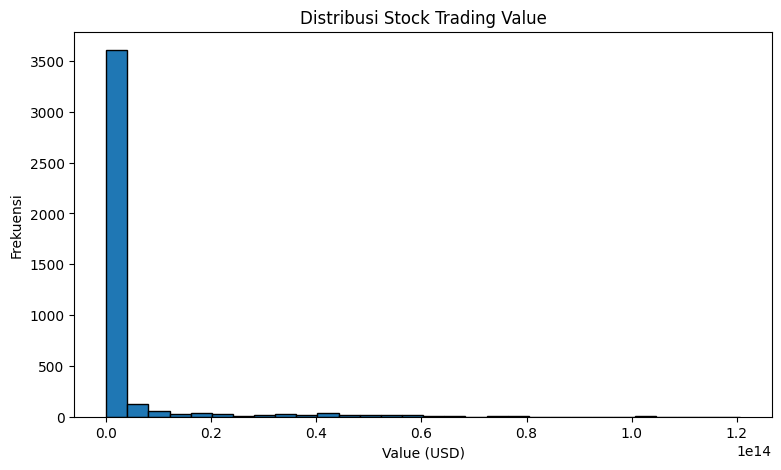

In [ ]:
# Statistik deskriptif tambahan
print("Statistik deskriptif Value (USD):")
display(df['Value (USD)'].describe())

# Histogram distribusi nilai trading
plt.figure(figsize=(9,5))
plt.hist(df['Value (USD)'], bins=30, edgecolor='black')
plt.title('Distribusi Stock Trading Value')
plt.xlabel('Value (USD)')
plt.ylabel('Frekuensi')
plt.show()

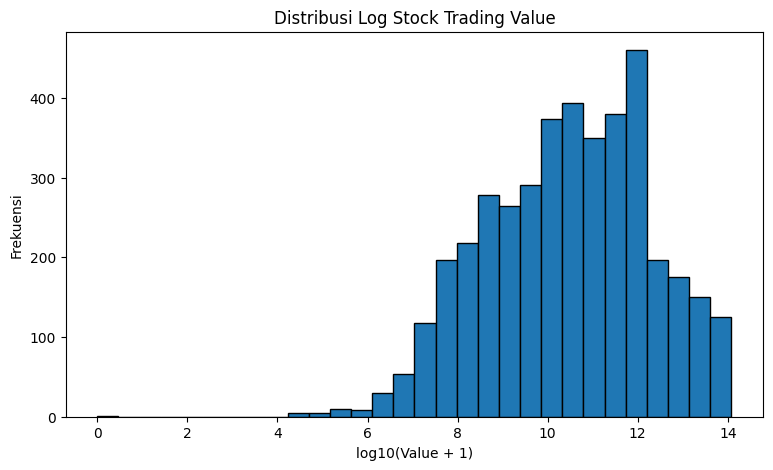

In [ ]:
# Karena data sangat besar dan right-skewed, gunakan log transform
df['log_value'] = np.log10(df['Value (USD)'] + 1)

# Histogram log transform
plt.figure(figsize=(9,5))
plt.hist(df['log_value'], bins=30, edgecolor='black')
plt.title('Distribusi Log Stock Trading Value')
plt.xlabel('log10(Value + 1)')
plt.ylabel('Frekuensi')
plt.show()

<Figure size 800x500 with 0 Axes>

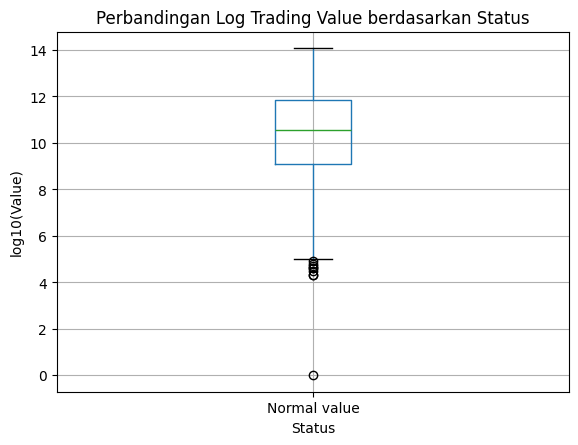

In [ ]:
# Boxplot berdasarkan status
plt.figure(figsize=(8,5))
df.boxplot(column='log_value', by='Status')
plt.title('Perbandingan Log Trading Value berdasarkan Status')
plt.suptitle('')
plt.xlabel('Status')
plt.ylabel('log10(Value)')
plt.show()

**Interpretasi:**

### a) Statistik deskriptif `Value (USD)`

Hasil statistik deskriptif memperlihatkan bahwa distribusi nilai transaksi pasar saham memiliki rentang yang sangat lebar. Mayoritas negara memiliki nilai transaksi relatif kecil dibanding beberapa negara dengan aktivitas pasar saham sangat besar.

Beberapa poin penting:
- Nilai minimum adalah 0 USD
- Nilai maksimum mencapai sekitar 1.2 × 10¹⁴ USD
- Rata-rata sebesar 3.39 × 10¹² USD
- Median hanya sekitar 3.58 × 10¹⁰ USD

Perbedaan yang sangat besar antara mean dan median menunjukkan bahwa distribusi data bersifat right **skewed (miring ke kanan)**. Artinya, terdapat sejumlah kecil observasi dengan nilai transaksi sangat besar yang menarik rata-rata menjadi jauh lebih tinggi.

Kondisi tersebut menunjukkan adanya **outlier alami** dalam data ekonomi global, terutama dari negara dengan kapitalisasi pasar dan aktivitas trading yang sangat besar.

---

### b) Histogram distribusi `Value (USD)`

Histogram awal menunjukkan distribusi data sangat tidak simetris dan cenderung **right skewed**.

Akibatnya:

* distribusi memanjang ke sisi kanan,
* visualisasi menjadi kurang optimal,
* pola distribusi sulit diamati secara jelas.

### c) Histogram setelah log transform

Transformasi log dilakukan menggunakan:
#### **log₁₀(Value + 1)**

Setelah transformasi log:

* distribusi menjadi lebih mendekati simetris,
* skewness berkurang,
* nilai ekstrem menjadi lebih terkompresi,
* pola distribusi data lebih mudah diamati.

Transformasi ini penting karena banyak metode statistik parametrik bekerja lebih baik pada data yang distribusinya lebih stabil dan tidak terlalu skewed.
Selain itu, log transform membantu mengurangi pengaruh outlier ekstrem pada analisis.

### d) Boxplot berdasarkan `Status`

Boxplot digunakan untuk membandingkan distribusi `log_value` berdasarkan kategori `Status`.

Namun, hasil eksplorasi menunjukkan bahwa seluruh observasi hanya memiliki satu kategori yaitu `"Normal value"`.

Akibatnya tidak terdapat variasi kelompok dan boxplot tidak memberikan perbandingan antar kategori. Karena hanya terdapat satu kelas, variabel ini kemungkinan tidak relevan digunakan dalam uji hipotesis berbasis perbandingan kelompok.


## 4) Perumusan Uji Hipotesis

### Uji Hipotesis 1 — One Sample t-Test

Uji ini digunakan untuk mengetahui apakah rata-rata log nilai transaksi saham global berbeda dari suatu nilai acuan tertentu. Karena variabel berbentuk numerik kontinu dan standar deviasi populasi tidak diketahui, digunakan one-sample t-test.

In [ ]:
# Hipotesis:
# H0 : mean log_value = 10
# HA : mean log_value != 10

alpha = 0.05
mu0 = 10

sample = df['log_value'].dropna()

t_stat, p_value = stats.ttest_1samp(sample, popmean=mu0)

print("One Sample t-Test")
print(f"n           : {len(sample)}")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

if p_value < alpha:
    print("Keputusan   : Tolak H0")
else:
    print("Keputusan   : Gagal menolak H0")

One Sample t-Test
n           : 4080
t-statistic : 15.3025
p-value     : 0.0000
Keputusan   : Tolak H0


###Uji Hipotesis 2 — Two Sample t-Test

Uji ini bertujuan membandingkan rata-rata nilai transaksi saham antara dua kelompok tahun berbeda. Pengelompokan dilakukan untuk melihat apakah aktivitas pasar saham modern berbeda dibanding periode lama.

Welch Two Sample t-Test
t-statistic : -9.1659
p-value     : 0.0000
Keputusan   : Tolak H0


/tmp/ipykernel_643/3580970115.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([old_period, new_period], labels=['< 2000', '>= 2000'])


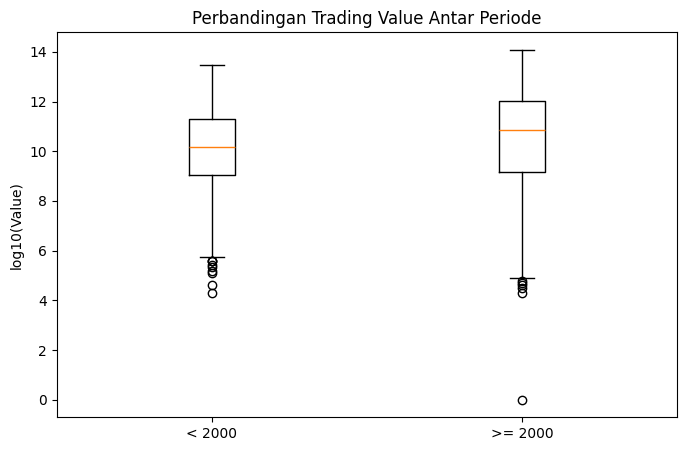

In [ ]:
# Membuat kelompok tahun
old_period = df[df['Year'] < 2000]['log_value']
new_period = df[df['Year'] >= 2000]['log_value']

# Hipotesis:
# H0 : mean lama = mean baru
# HA : mean lama != mean baru

t_stat, p_value = stats.ttest_ind(old_period, new_period, equal_var=False)

print("Welch Two Sample t-Test")
print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

# Keputusan
if p_value < alpha:
    print("Keputusan   : Tolak H0")
else:
    print("Keputusan   : Gagal menolak H0")

# Visualisasi
plt.figure(figsize=(8,5))
plt.boxplot([old_period, new_period], labels=['< 2000', '>= 2000'])
plt.title('Perbandingan Trading Value Antar Periode')
plt.ylabel('log10(Value)')
plt.show()

###Uji Hipotesis 3 — Chi-Square Independence Test

Uji chi-square digunakan untuk mengetahui apakah terdapat hubungan antara kategori tahun dan status data. Karena kedua variabel bersifat kategorik, maka chi-square independence test sesuai digunakan.

In [ ]:
# contingency table
df['year_group'] = np.where(df['Year'] < 2000, 'Old', 'New')
contingency = pd.crosstab(df['year_group'], df['Status'])

# chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print("Chi-Square Test of Independence")
print(contingency)
print(f"\nChi2 statistic : {chi2:.4f}")
print(f"p-value        : {p:.4f}")

if p < alpha:
    print("Keputusan      : Tolak H0")
else:
    print("Keputusan      : Gagal menolak H0")

Chi-Square Test of Independence
Status      Normal value
year_group              
New                 2645
Old                 1435

Chi2 statistic : 0.0000
p-value        : 1.0000
Keputusan      : Gagal menolak H0


**Interpretasi:**

### a) Uji Hipotesis 1 — One Sample t-Test

Uji t satu sampel dilakukan untuk menguji apakah rata-rata log10(Value + 1) berbeda dari 10. Hipotesis yang digunakan adalah (H_0: \mu = 10) dan (H_A: \mu \ne 10). Hasil uji memberikan (t = 15.3025) dengan p-value = 0.0000. Karena p-value lebih kecil dari (\alpha = 0.05), maka keputusan uji adalah menolak (H_0). Dengan demikian, berdasarkan data sampel, terdapat bukti statistik yang cukup bahwa rata-rata log10(Value + 1) berbeda dari 10.

### b) Uji Hipotesis 2 — Two Sample t-Test

Uji t dua sampel independen dilakukan untuk membandingkan rata-rata log trading value antara kelompok tahun sebelum 2000 dan setelah 2000. Hasil uji memberikan p-value = 0.0000. Pada tingkat signifikansi 5%, keputusan uji adalah menolak (H_0). Rata-rata kelompok sebelum 2000 adalah lebih rendah dibanding kelompok setelah 2000 (ditunjukkan oleh nilai t negatif). Secara substantif, terdapat perbedaan rata-rata log trading value sebesar yang tercermin dalam data, sehingga aktivitas pasar saham pada periode modern berbeda secara statistik dibanding periode lama.

### c) Uji Hipotesis 3 — Chi-Square Independence Test

Uji chi-square dilakukan untuk menguji apakah year_group dan Status saling independen. Hasil uji memberikan (\chi^2 = 0.0000) dengan p-value = 1.0000. Karena p-value lebih besar dari 0.05, maka keputusan uji adalah gagal menolak (H_0). Hal ini menunjukkan bahwa tidak terdapat bukti statistik adanya hubungan antara kelompok tahun (Old dan New) dengan status data. Dengan demikian, berdasarkan sampel ini, distribusi Status terlihat sama pada setiap kelompok tahun.


### **Interpretasi**

### a) Uji Hipotesis 1 — One Sample t-Test

Uji t satu sampel dilakukan untuk menguji apakah rata-rata log10(Value + 1) berbeda dari 10.

- Hipotesis yang digunakan:

   $H_0: \mu = 10$

   $H_A: \mu \ne 10$

- Tingkat signifikansi: 5%

- Hasil uji memberikan $t = 15.3025$ dengan p-value = 0.0000.

- Karena p-value lebih kecil dari 0.05, maka $H_0$ ditolak.

Dengan demikian, berdasarkan data sampel, terdapat bukti statistik yang cukup bahwa rata-rata log10(Value + 1) berbeda dari 10.

### b) Uji Hipotesis 2 — Two Sample t-Test

Uji t dua sampel independen dilakukan untuk membandingkan rata-rata log trading value antara kelompok tahun sebelum 2000 dan setelah 2000.

- Hipotesis yang digunakan adalah

   $H_0: \mu_{old} = \mu_{new}$

   $H_A: \mu_{old} \ne \mu_{new}$

- Hasil uji memberikan p-value = 0.0000.

- Tingkat signifikansi: 5%

- Rata-rata kelompok sebelum 2000 lebih rendah dibanding kelompok setelah 2000 (ditunjukkan oleh nilai t negatif).

Dengan demikian, terdapat perbedaan rata-rata log trading value antara dua periode tersebut, yang menunjukkan adanya perubahan aktivitas pasar saham dari waktu ke waktu.

### c) Uji Hipotesis 3 — Chi-Square Independence Test

Uji chi-square dilakukan untuk menguji apakah year_group dan Status saling independen.

- Hipotesis yang digunakan:

   $H_0$: year_group dan Status bersifat independen

   $H_A$: year_group dan Status tidak independen

- Tingkat signifikansi: 5%

- Hasil uji memberikan $\chi^2 = 0.0000$ dengan p-value = 1.0000.

- Karena p-value lebih besar dari 0.05, maka $H_0$ tidak ditolak.

Hal ini menunjukkan bahwa tidak terdapat bukti adanya hubungan antara kelompok tahun (Old dan New) dengan status data. Dengan demikian, distribusi Status terlihat sama pada setiap kelompok tahun.

##5) Effect Size dan Makna Praktis

Selain signifikansi statistik, perlu dilakukan evaluasi besar efek agar hasil memiliki makna praktis. Cohen’s d digunakan untuk mengukur besar perbedaan rata-rata antar kelompok

In [ ]:
# Effect size Cohen's d
mean_old = old_period.mean()
mean_new = new_period.mean()

std_old = old_period.std(ddof=1)
std_new = new_period.std(ddof=1)

n1 = len(old_period)
n2 = len(new_period)

# pooled std
sp = np.sqrt(((n1 - 1)*(std_old**2) + (n2 - 1)*(std_new**2)) / (n1 + n2 - 2))
cohens_d = (mean_new - mean_old) / sp

print("Effect Size (Cohen's d)")
print(f"Cohen's d : {cohens_d:.4f}")

# Interpretasi sederhana
if abs(cohens_d) < 0.2:
    interpretation = "Efek sangat kecil"
elif abs(cohens_d) < 0.5:
    interpretation = "Efek kecil"
elif abs(cohens_d) < 0.8:
    interpretation = "Efek sedang"
else:
    interpretation = "Efek besar"

print("Interpretasi:", interpretation)

Effect Size (Cohen's d)
Cohen's d : 0.2828
Interpretasi: Efek kecil


**Interpretasi:**

Berikut interpretasi sesuai gaya penulisan kamu:

---

## **5) Effect Size dan Makna Praktis**

Effect size digunakan untuk menilai seberapa besar perbedaan yang terjadi secara praktis, tidak hanya secara statistik. Pada analisis ini digunakan **Cohen’s d** untuk mengukur perbedaan rata-rata log trading value antara periode sebelum 2000 dan setelah 2000.

Hasil perhitungan menunjukkan:

* Cohen’s d = 0.2828
* Interpretasi: efek kecil

Artinya, meskipun uji hipotesis menunjukkan perbedaan yang signifikan secara statistik, besarnya perbedaan rata-rata antar periode tergolong kecil secara praktis.


##6) Kesimpulan


Berdasarkan hasil analisis uji hipotesis, terdapat perbedaan rata-rata log trading value antara periode sebelum 2000 dan setelah 2000 secara statistik. Selain itu, rata-rata nilai transaksi juga berbeda secara signifikan dari nilai acuan pada uji satu sampel.

Namun, berdasarkan evaluasi effect size, perbedaan tersebut tergolong kecil secara praktis. Hal ini menunjukkan bahwa meskipun perubahan aktivitas pasar saham secara statistik terdeteksi, dampak praktisnya tidak terlalu besar.

Secara keseluruhan, hasil analisis ini menunjukkan bahwa data memiliki perbedaan yang signifikan secara statistik, tetapi perlu kehati-hatian dalam menginterpretasikan dampak nyatanya dalam konteks ekonomi atau pasar keuangan.

---

# Jawaban Checkpoint

Hypothesis Testing in Practice Null Hypothesis, p-values, dan Basic Tests  

## Checkpoint 1: Konsep Dasar Uji Hipotesis

1. Perbedaan H0 dan HA  
H0 atau hipotesis nol adalah pernyataan awal yang diasumsikan benar sebelum ada bukti dari data. Biasanya H0 menyatakan tidak ada perbedaan, tidak ada pengaruh, atau suatu parameter sama dengan nilai tertentu.

   HA atau hipotesis alternatif adalah kebalikan dari H0 yang menyatakan adanya perbedaan, pengaruh, atau perubahan terhadap nilai tertentu (lebih besar, lebih kecil, atau tidak sama).

2. Kenapa keputusan ditulis “menolak” atau “gagal menolak”, bukan “menerima H0”?  
Karena uji hipotesis tidak membuktikan kebenaran H0. Jika p-value besar, artinya data tidak cukup kuat untuk menolak H0, bukan berarti H0 pasti benar.  
Oleh karena itu, istilah yang tepat adalah **gagal menolak H0**, bukan menerima H0.

3. Makna α = 0.05  
α = 0.05 berarti kita menerima risiko 5% untuk melakukan kesalahan tipe I, yaitu menolak H0 padahal H0 sebenarnya benar.

4. Perbedaan kesalahan Tipe I dan Tipe II  
- **Tipe I:** menolak H0 padahal H0 benar (probabilitas = α)  
- **Tipe II:** gagal menolak H0 padahal H0 salah (probabilitas = β)  

## Checkpoint 2: Interpretasi p-value

1. Arti p-value  
p-value adalah peluang mendapatkan hasil yang sama ekstrem atau lebih ekstrem dari data, dengan asumsi H0 benar.

2. Kenapa p-value bukan probabilitas H0 benar?  
Karena p-value dihitung dengan asumsi H0 sudah benar. Jadi yang dihitung adalah seberapa “tidak biasa” data jika H0 benar, bukan peluang H0 benar setelah melihat data.

3. Perbedaan uji satu sisi dan dua sisi  
- **Satu sisi:** hanya melihat arah tertentu (lebih besar atau lebih kecil)  
- **Dua sisi:** melihat dua arah (berbeda dari nilai acuan)

4. Keputusan jika p-value = 0.03 dan α = 0.05  
Karena 0.03 < 0.05, maka keputusan uji adalah **menolak H0**.

## Checkpoint 3: Uji Proporsi

1. Parameter yang diuji  
Parameter yang diuji adalah **proporsi populasi (p)** dengan H0: p = 0.70

2. Kenapa uji satu sisi kiri?  
Karena hipotesis penelitian ingin mengecek apakah proporsi lebih kecil dari 70%, bukan sekadar berbeda, dengn HA: p < 0.70

3. Perbandingan p-value z-test dan binomial  
p-value z-test ≈ 0.0555  
p-value binomial ≈ 0.0694  

   Keduanya > 0.05 sehingga keputusannya sama, yaitu **gagal menolak H0**.

4. Asumsi uji proporsi normal  
Pendekatan normal digunakan jika np0 ≥ 10 dan n(1 − p0) ≥ 10  

## Checkpoint 4: Uji t dan Confidence Interval

1. Kenapa pakai uji t, bukan z?  
Karena standar deviasi populasi tidak diketahui sehingga digunakan standar deviasi sampel.

2. Arti df = n − 1  
df adalah derajat bebas, yaitu jumlah informasi bebas setelah mengestimasi mean.  
Pada uji t satu sampel: df = n − 1.

3. Hubungan p-value dan confidence interval  
Pada uji dua sisi:  
- jika μ0 berada dalam CI → gagal menolak H0  
- jika μ0 di luar CI → menolak H0  

4. Interpretasi waktu belajar  
- Rata-rata sampel = 3.2791  
- p-value = 0.0865  

   Karena 0.0865 > 0.05, maka **gagal menolak H0**. Artinya belum ada bukti cukup bahwa rata-rata waktu belajar berbeda dari 3 jam per hari.

## Checkpoint 5: Paired t-test

1. Kenapa pakai paired t-test?  
Karena data pre-test dan post-test berasal dari orang yang sama, sehingga saling berpasangan (tidak independen).

2. Variabel yang diuji  
Yang diuji adalah selisih setiap pasangan data:  
Di = post-test − pre-test

3. Arti H0: μD = 0  
Artinya tidak ada perubahan rata-rata antara pre-test dan post-test.

4. Interpretasi hasil  
- Rata-rata pre-test = 64.5810  
- Rata-rata post-test = 70.8231  
- p-value sangat kecil (< 0.05)  

Maka keputusannya adalah **menolak H0**. Artinya terdapat bukti kuat bahwa skor meningkat setelah pembelajaran.

---

# 6. Ringkasan

| Topik | Keputusan | Interpretasi |
|------|----------|--------------|
| Uji proporsi | Gagal menolak H0 | Belum cukup bukti proporsi < 70% |
| Uji t satu sampel | Gagal menolak H0 | Waktu belajar tidak berbeda dari 3 jam |
| Paired t-test | Menolak H0 | Skor meningkat signifikan setelah perlakuan |